## 第一部分：数据获取与处理

In [1]:
import pandas as pd
import numpy as np
import os

# 定义原始数据和输出路径
raw_path = "./data/raw/"
clean_path = "./data/clean/"

# 确保输出文件夹存在
os.makedirs(clean_path, exist_ok=True)

print("库导入完成，路径设置完毕。")

库导入完成，路径设置完毕。


### 1.1 读取原始数据

In [2]:
files = [
    "balance_sheet.csv",
    "income_stmt.csv",
    "cashflow.csv",
    "ownership.csv",
    "industry.csv",
    "st_flag.csv",
    "m2.csv",
    "liquidity.csv"        
]

for f in files:
    try:
        df = pd.read_csv(raw_path + f)
        print(f"===== {f} =====")
        print("列名：", df.columns.tolist())
        print(f"形状：{df.shape}")
        print("前2行样本：")
        display(df.head(2))
        print("\n")
    except Exception as e:
        print(f"读取 {f} 时出错：{e}\n")

===== balance_sheet.csv =====
列名： ['Stkcd', 'ShortName', 'Accper', 'Typrep', 'A001212000', 'A001000000', 'A002000000']
形状：(60568, 7)
前2行样本：


,Stkcd,ShortName,Accper,Typrep,A001212000,A001000000,A002000000
0,1,深发展A,2009-12-31,A,1.714461e+09,5.878110e+11,5.673414e+11
1,1,深发展A,2010-12-31,A,2.392293e+09,7.272071e+11,6.940095e+11




===== income_stmt.csv =====
列名： ['Stkcd', 'ShortName', 'Accper', 'Typrep', 'B002000000']
形状：(58811, 5)
前2行样本：


,Stkcd,ShortName,Accper,Typrep,B002000000
0,1,深发展A,2010-12-31,A,6.283816e+09
1,1,深发展A,2011-12-31,A,1.039049e+10




===== cashflow.csv =====
列名： ['Stkcd', 'ShortName', 'Accper', 'Typrep', 'D000103000', 'D000119000', 'D000120000', 'D000104000', 'D000105000']
形状：(58806, 9)
前2行样本：


...

,Symbol,ShortName,EndDate,LISTINGSTATE
0,1,深发展A,2010-12-31,正常上市
1,1,深发展A,2011-12-31,正常上市




===== m2.csv =====
列名： ['Staper', 'Efq0101']
形状：(17, 2)
前2行样本：


,Staper,Efq0101
0,2009-12,61022.45
1,2010-12,72585.18




===== liquidity.csv =====
列名： ['Stkcd', 'ShortName', 'Accper', 'Typrep', 'A001100000', 'A002100000']
形状：(58811, 6)
前2行样本：


,Stkcd,ShortName,Accper,Typrep,A001100000,A002100000
0,1,深发展A,2010-12-31,A,NaN,NaN
1,1,深发展A,2011-12-31,A,NaN,NaN


### 1.2 字段重命名+合并

In [3]:
# ========== 资产负债表 ==========
bs = pd.read_csv(raw_path + "balance_sheet.csv")
bs = bs.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'date',
    'Typrep': 'typrep',
    'A001212000': 'fixed_assets',
    'A001000000': 'total_assets',
    'A002000000': 'total_liab'
})
bs['year'] = pd.to_datetime(bs['date']).dt.year
bs = bs[bs['typrep'] == 'A'].copy()
# 统一 stkcd 为6位字符串
bs['stkcd'] = bs['stkcd'].astype(int).astype(str).str.zfill(6)
print("bs 完成，年份：", bs['year'].min(), "-", bs['year'].max())

# ========== 利润表 ==========
inc = pd.read_csv(raw_path + "income_stmt.csv")
inc = inc.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'date',
    'Typrep': 'typrep',
    'B002000000': 'net_profit'
})
inc['year'] = pd.to_datetime(inc['date']).dt.year
inc = inc[inc['typrep'] == 'A'].copy()
inc['stkcd'] = inc['stkcd'].astype(int).astype(str).str.zfill(6)
print("inc 完成，年份：", inc['year'].min(), "-", inc['year'].max())

# ========== 现金流量表（间接法） ==========
cf = pd.read_csv(raw_path + "cashflow.csv")
cf = cf.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'date',
    'Typrep': 'typrep',
    'D000103000': 'd1',
    'D000119000': 'd2',
    'D000120000': 'd3',
    'D000104000': 'd4',
    'D000105000': 'd5'
})
cf['year'] = pd.to_datetime(cf['date']).dt.year
cf = cf[cf['typrep'] == 'A'].copy()
cf['depr_total'] = cf[['d1','d2','d3','d4','d5']].fillna(0).sum(axis=1)
cf['stkcd'] = cf['stkcd'].astype(int).astype(str).str.zfill(6)
print("cf 完成，年份：", cf['year'].min(), "-", cf['year'].max())

# ========== 流动资产/流动负债（单独表） ==========
liq = pd.read_csv(raw_path + "liquidity.csv")
liq = liq.rename(columns={
    'Stkcd': 'stkcd',
    'Accper': 'date',
    'Typrep': 'typrep',
    'A001100000': 'current_assets',
    'A002100000': 'current_liab'
})
liq['year'] = pd.to_datetime(liq['date']).dt.year
liq = liq[liq['typrep'] == 'A'].copy()
liq['stkcd'] = liq['stkcd'].astype(int).astype(str).str.zfill(6)
print("liq 完成，年份：", liq['year'].min(), "-", liq['year'].max())

# ========== 股权性质 ==========
own = pd.read_csv(raw_path + "ownership.csv")
own = own.rename(columns={
    'Symbol': 'stkcd',
    'EndDate': 'date',
    'ActualControllerNatureID': 'controller'
})
own['year'] = pd.to_datetime(own['date']).dt.year
own['controller_last'] = own['controller'].astype(str).str.split(',').str[-1].str.strip()
own['stkcd'] = own['stkcd'].astype(int).astype(str).str.zfill(6)
print("own 完成，年份：", own['year'].min(), "-", own['year'].max())

# ========== 行业分类 ==========
ind = pd.read_csv(raw_path + "industry.csv")
ind = ind.rename(columns={
    'Symbol': 'stkcd',
    'EndDate': 'date',
    'IndustryCode': 'ind_code'
})
ind['year'] = pd.to_datetime(ind['date']).dt.year
ind['stkcd'] = ind['stkcd'].astype(int).astype(str).str.zfill(6)
print("ind 完成，年份：", ind['year'].min(), "-", ind['year'].max())

# ========== ST/PT 标记 ==========
st = pd.read_csv(raw_path + "st_flag.csv")
st = st.rename(columns={
    'Symbol': 'stkcd',
    'EndDate': 'date',
    'LISTINGSTATE': 'listing_state'
})
st['year'] = pd.to_datetime(st['date']).dt.year
st['stkcd'] = st['stkcd'].astype(int).astype(str).str.zfill(6)
print("st 完成，年份：", st['year'].min(), "-", st['year'].max())

# ========== M2 ==========
m2 = pd.read_csv(raw_path + "m2.csv")
m2 = m2.rename(columns={'Staper': 'date_raw', 'Efq0101': 'M2'})

def parse_m2_year(x):
    import re
    x = str(x).strip()
    if re.match(r'\d{4}-\d{2}', x):
        return int(x[:4])
    parts = x.split('-')
    if len(parts) == 2:
        try:
            yr = int(parts[1])
            if yr < 100:
                yr += 2000
            return yr
        except:
            pass
    return None

m2['year'] = m2['date_raw'].apply(parse_m2_year)
print("m2 完成，年份：", m2['year'].min(), "-", m2['year'].max())

bs 完成，年份： 2009 - 2025
inc 完成，年份： 2010 - 2025
cf 完成，年份： 2010 - 2025
liq 完成，年份： 2010 - 2025
own 完成，年份： 2010 - 2025
ind 完成，年份： 2010 - 2025
st 完成，年份： 2010 - 2025
m2 完成，年份： 2009 - 2025


In [4]:
# 合并大宽表
# 以资产负债表为底表（2009-2025），左连接其他表
merged = bs[['stkcd','year','total_assets','total_liab','fixed_assets']].copy()

# 合并利润表
merged = merged.merge(
    inc[['stkcd','year','net_profit']], 
    on=['stkcd','year'], how='left'
)

# 合并现金流量表（折旧摊销总额 depr_total）
merged = merged.merge(
    cf[['stkcd','year','depr_total']], 
    on=['stkcd','year'], how='left'
)

# 合并流动资产负债（如果 liquidity 表没有单独下载，则在资产负债表里已有；这里再补）
# 注意：你的流动性单独表是 liquidity.csv，我们已经导入为 liq
merged = merged.merge(
    liq[['stkcd','year','current_assets','current_liab']], 
    on=['stkcd','year'], how='left'
)

# 合并股权性质（controller_last）
merged = merged.merge(
    own[['stkcd','year','controller_last']], 
    on=['stkcd','year'], how='left'
)

# 合并行业分类（ind_code）
merged = merged.merge(
    ind[['stkcd','year','ind_code']], 
    on=['stkcd','year'], how='left'
)

# 合并上市状态（listing_state）
merged = merged.merge(
    st[['stkcd','year','listing_state']], 
    on=['stkcd','year'], how='left'
)

print("合并完成，形状：", merged.shape)
display(merged.head())

合并完成，形状： (60568, 12)


,stkcd,year,total_assets,total_liab,fixed_assets,net_profit,depr_total,current_assets,current_liab,controller_last,ind_code,listing_state
0,000001,2009,5.878110e+11,5.673414e+11,1.714461e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000001,2010,7.272071e+11,6.940095e+11,2.392293e+09,6.283816e+09,4.924520e+08,NaN,NaN,1230,I0199,正常上市
2,000001,2011,1.258177e+12,1.182796e+12,3.524265e+09,1.039049e+10,9.098600e+08,NaN,NaN,1230,I0199,正常上市
3,000001,2012,1.606537e+12,1.521738e+12,3.536443e+09,1.351078e+10,1.256366e+09,0.0,0.0,1230,J66,正常上市
4,000001,2013,1.891741e+12,1.779660e+12,3.694000e+09,1.523100e+10,1.402000e+09,0.0,0.0,1230,J66,正常上市


### 1.3 变量构造 
#### （包括行业分类处理）

In [5]:
# ============================================================
# 起点：merged 已生成（包含2009-2025所有数据）
# 本 Cell 一次性完成：变量构造 → SOE定义 → 样本筛选 → 保存最终数据
# ============================================================
import numpy as np
import pandas as pd

# 复制一份，保留原 merged 不动
df = merged.copy()

# ---------- 按公司-年份排序 ----------
df = df.sort_values(['stkcd', 'year']).copy()

# ---------- 计算基础变量（此时还保留2009年）----------
df['Lev']   = df['total_liab'] / df['total_assets']
df['NPR']   = df['net_profit'] / df['total_assets']
df['Size']  = np.log(df['total_assets'])
df['Tang']  = df['fixed_assets'] / df['total_assets']
df['NDTS']  = df['depr_total'] / df['total_assets']
df['Liq']   = df['current_assets'] / df['current_liab']

# ---------- SOE（修正定义）----------
soe_yes = ['1100', '1200', '1210', '1220', '1230', '2100', '2120']
df['SOE'] = df['controller_last'].apply(
    lambda x: 1 if str(x).strip() in soe_yes else 0
)

# ---------- Growth（滞后总资产，保留2009年做滞后期）----------
df['total_assets_lag'] = df.groupby('stkcd')['total_assets'].shift(1)
df['Growth'] = (df['total_assets'] - df['total_assets_lag']) / df['total_assets_lag']

# ---------- 行业固定效应代码 ----------
def industry_fix(code):
    code = str(code).strip()
    if code.startswith('C'):
        return code[:3]
    else:
        return code[0]
df['industry_fe'] = df['ind_code'].astype(str).apply(industry_fix)

# ---------- 只保留2010-2025（此时2009年已完成滞后使命）----------
df = df[df['year'].between(2010, 2025)].copy()
print(f"2010-2025 年观测数：{df.shape[0]}")

2010-2025 年观测数：58811


c:\Users\86134\anaconda3\lib\site-packages\ipykernel_launcher.py:17: RuntimeWarning: divide by zero encountered in log


### 1.4 样本筛选

In [6]:
# ============================================================
# 样本筛选流程表（一步到位）
# ============================================================
# 初始样本
n0 = df.shape[0]
n_firm0 = df['stkcd'].nunique()

# 剔除金融保险（行业代码 J 开头）
mask_fin = df['ind_code'].str.startswith('J', na=False)
n1_removed = mask_fin.sum()
df = df[~mask_fin].copy()
n1 = df.shape[0]
n_firm1 = df['stkcd'].nunique()

# 剔除曾被 ST/PT 的公司
st_firms = df[df['listing_state'].isin(['ST', '*ST', '暂停上市'])]['stkcd'].unique()
mask_st = df['stkcd'].isin(st_firms)
n2_removed = mask_st.sum()
df = df[~mask_st].copy()
n2 = df.shape[0]
n_firm2 = df['stkcd'].nunique()

# 剔除 Lev > 1
n3_removed = (df['Lev'] > 1).sum()
df = df[df['Lev'] <= 1].copy()
n3 = df.shape[0]
n_firm3 = df['stkcd'].nunique()

# 剔除关键变量缺失（reg_vars 包含回归用到的所有变量）
reg_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE']
n4_removed = df[reg_vars].isna().any(axis=1).sum()
df_final = df.dropna(subset=reg_vars).copy()
n4 = df_final.shape[0]
n_firm4 = df_final['stkcd'].nunique()

# 输出筛选表格
print("\n### 样本筛选流程表\n")
print("| 筛选步骤 | 剔除观测数 | 剩余观测数 | 剩余公司数 |")
print("|---|---|---|---|")
print(f"| 初始样本 | — | {n0} | {n_firm0} |")
print(f"| 剔除金融保险 | {n1_removed} | {n1} | {n_firm1} |")
print(f"| 剔除 ST/PT | {n2_removed} | {n2} | {n_firm2} |")
print(f"| 剔除 Lev > 1 | {n3_removed} | {n3} | {n_firm3} |")
print(f"| 剔除缺失值 | {n4_removed} | {n4} | {n_firm4} |")
print(f"| **最终样本** | | **{n4}** | **{n_firm4}** |")



### 样本筛选流程表

| 筛选步骤 | 剔除观测数 | 剩余观测数 | 剩余公司数 |
|---|---|---|---|
| 初始样本 | — | 58811 | 5703 |
| 剔除金融保险 | 1479 | 57332 | 5659 |
| 剔除 ST/PT | 9894 | 47438 | 4940 |
| 剔除 Lev > 1 | 23 | 47415 | 4940 |
| 剔除缺失值 | 3704 | 43711 | 4825 |
| **最终样本** | | **43711** | **4825** |


### 1.5 异常值处理（Winsorize）

对 Lev、NPR、Tang、Growth、NDTS、Liq 在每年分别进行双侧 1% 缩尾处理，并绘制缩尾前后箱型图。

In [7]:
winsor_vars = ['Lev', 'NPR', 'Tang', 'Growth', 'NDTS', 'Liq']
for v in winsor_vars:
    df_final[v + '_w'] = df_final.groupby('year')[v].transform(
        lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))
    )

print("\nWinsorize 完成，新增列：", [v+'_w' for v in winsor_vars])

# ============================================================
# 计算 M2_growth 并合并到 df_final
# ============================================================
m2_sorted = m2.sort_values('year').copy()
m2_sorted['M2_lag'] = m2_sorted['M2'].shift(1)
m2_sorted['M2_growth'] = (m2_sorted['M2'] - m2_sorted['M2_lag']) / m2_sorted['M2_lag'] * 100
m2_growth_df = m2_sorted[m2_sorted['year'].between(2010, 2025)][['year', 'M2_growth']].copy()
df_final = df_final.merge(m2_growth_df, on='year', how='left')

print("M2_growth 合并完成，缺失数：", df_final['M2_growth'].isna().sum())


Winsorize 完成，新增列： ['Lev_w', 'NPR_w', 'Tang_w', 'Growth_w', 'NDTS_w', 'Liq_w']
M2_growth 合并完成，缺失数： 0


#### 缩尾前后箱型图对比
展示 Lev、NPR、Growth 三个变量缩尾前后的分布。

In [8]:
# ============================================================
# 设置中文字体 & 输出路径
# ============================================================
import matplotlib.pyplot as plt
import matplotlib

# 解决中文方块问题（根据你的系统，SimHei 通常可用；若无，改为 'Microsoft YaHei'）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 确保输出目录在 P03 内
import os
os.makedirs('./output/figures/', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_vars = ['Lev', 'NPR', 'Growth']
titles = ['资产负债率 (Lev)', '净利润率 (NPR)', '成长率 (Growth)']

for i, var in enumerate(plot_vars):
    ax = axes[i]
    # 取原始值和缩尾后值（剔除缺失，确保配对）
    raw = df_final[var].dropna()
    w   = df_final[var + '_w'].dropna()
    ax.boxplot([raw, w], labels=['原始', 'Winsorize后'], widths=0.6)
    ax.set_title(titles[i])
    ax.set_ylabel('数值')

plt.tight_layout()
plt.savefig('./output/figures/fig0_winsorize_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("箱型图已保存至 ./output/figures/fig0_winsorize_boxplot.png")

<Figure size 1800x500 with 3 Axes>

箱型图已保存至 ./output/figures/fig0_winsorize_boxplot.png


In [9]:
# ============================================================
# 保存最终数据（路径 data/clean/）
# ============================================================
os.makedirs('./data/clean/', exist_ok=True)
df_final.to_csv('./data/clean/df_final.csv', index=False)
print(f"\n最终数据已保存至 ./data/clean/df_final.csv")
print(f"观测数：{df_final.shape[0]}，公司数：{df_final['stkcd'].nunique()}")
print(f"年份范围：{df_final['year'].min()} - {df_final['year'].max()}")


最终数据已保存至 ./data/clean/df_final.csv
观测数：43711，公司数：4825
年份范围：2010 - 2025


## 第二部分：描述性统计

### 2.1 主要变量描述性统计
#### （分全样本、SOE、非SOE 三组呈现）

In [10]:
import pandas as pd
import numpy as np
from scipy import stats

# 读取最终数据（如果 kernel 重启过，可直接读 CSV）
df = pd.read_csv('./data/clean/df_final.csv')

# 定义要展示的变量（使用缩尾后的变量）
vars_show = ['Lev_w', 'NPR_w', 'Size', 'Tang_w', 'Growth_w', 'NDTS_w']
var_labels = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS']

def desc_table(data, var_list, label_list):
    """计算描述统计表"""
    result = pd.DataFrame(columns=['N','Mean','SD','P10','P25','Median','P75','P90'])
    for v, lb in zip(var_list, label_list):
        s = data[v].dropna()
        result.loc[lb] = [
            len(s),
            s.mean(),
            s.std(),
            s.quantile(0.10),
            s.quantile(0.25),
            s.median(),
            s.quantile(0.75),
            s.quantile(0.90)
        ]
    return result

# 全样本
full_desc = desc_table(df, vars_show, var_labels)
print("="*50)
print("全样本描述统计")
print("="*50)
print(full_desc.round(4))

# 分组
soe_desc = desc_table(df[df['SOE']==1], vars_show, var_labels)
private_desc = desc_table(df[df['SOE']==0], vars_show, var_labels)

print("\n" + "="*50)
print("国有企业 (SOE=1) 描述统计")
print("="*50)
print(soe_desc.round(4))

print("\n" + "="*50)
print("民营企业 (SOE=0) 描述统计")
print("="*50)
print(private_desc.round(4))

# 均值差异 t 检验（两独立样本）
print("\n" + "="*50)
print("均值差异 t 检验（国有企业 vs 民营企业）")
print("="*50)
for v, lb in zip(vars_show, var_labels):
    soe = df[df['SOE']==1][v].dropna()
    private = df[df['SOE']==0][v].dropna()
    t_stat, p_val = stats.ttest_ind(soe, private, equal_var=False)
    stars = ''
    if p_val < 0.01:
        stars = '***'
    elif p_val < 0.05:
        stars = '**'
    elif p_val < 0.1:
        stars = '*'
    print(f"{lb:>6}: 国企均值={soe.mean():.4f}, 民营均值={private.mean():.4f}, t={t_stat:.3f}, p={p_val:.4f} {stars}")

全样本描述统计
              N     Mean      SD      P10      P25   Median      P75      P90
Lev     43711.0   0.4053  0.1974   0.1451   0.2458   0.3972   0.5516   0.6751
NPR     43711.0   0.0392  0.0599  -0.0127   0.0141   0.0382   0.0687   0.1040
Size    43711.0  22.2132  1.4252  20.6602  21.2713  22.0248  22.9823  24.0588
Tang    43711.0   0.2052  0.1512   0.0339   0.0873   0.1752   0.2904   0.4211
Growth  43711.0   0.1466  0.2938  -0.0581   0.0077   0.0807   0.1921   0.3905
NDTS    43711.0   0.0253  0.0158   0.0077   0.0135   0.0225   0.0339   0.0462

国有企业 (SOE=1) 描述统计
              N     Mean      SD      P10      P25   Median      P75      P90
Lev     13388.0   0.4877  0.1949   0.2154   0.3394   0.4954   0.6380   0.7447
NPR     13388.0   0.0340  0.0482  -0.0012   0.0116   0.0305   0.0554   0.0879
Size    13388.0  23.0556  1.5114  21.2871  21.9561  22.8812  23.9381  25.0085
Tang    13388.0   0.2368  0.1848   0.0283   0.0835   0.1914   0.3587   0.5245
Growth  13388.0   0.1147  0.2544  -0.

## 2.1 主要变量描述性统计解读

最终样本共 43,711 个公司-年度观测值，覆盖 4,820 家公司。数据经过双侧 1% 缩尾处理，以下汇报缩尾后的变量（表中变量名省略 `_w` 后缀）。全样本、国有企业（SOE=1）和民营企业（SOE=0）的描述性统计见上表。

**全样本特征**
- 资产负债率（Lev）均值 0.405，中位数 0.397，整体杠杆水平约 40%，分布右偏（P90=0.675），少数企业杠杆较高。
- 净利润率（NPR）均值 0.039，中位数 0.038，约 10% 的公司处于亏损状态（P10=-0.013）。
- 企业规模（Size，总资产对数值）均值 22.21，对应总资产约 44 亿元，标准差 1.43，规模差异显著。
- 有形资产比例（Tang）均值 0.205，固定资产净值占总资产约五分之一。
- 成长率（Growth）均值 0.147，右偏分布（P75=0.192，P90=0.391），部分公司高速扩张。
- 非债务税盾（NDTS）均值 0.025，折旧摊销占总资产比例较低，分布较集中。

**产权性质差异**
- 国有企业杠杆率显著更高（均值 0.488 vs 民营 0.369），差异 0.119，t=59.41（p<0.001）。国企信贷优势明显，符合软约束预期。
- 国有企业盈利能力略低（均值 0.034 vs 民营 0.042），但盈利分布更集中（标准差 0.048 vs 0.064），显示国企利润波动较小。
- 国有企业规模显著更大（均值 23.06 vs 21.84，总资产约 102 亿元 vs 31 亿元），t=82.05（p<0.001）。
- 国有企业有形资产比例更高（0.237 vs 0.191），体现重资产倾向；但成长性较低（0.115 vs 0.161），多处于成熟期。
- 非债务税盾差异虽小（0.026 vs 0.025）但统计显著（t=8.80），国企可能拥有更多固定资产带来更高折旧。

总体来看，产权性质导致资本结构、盈利、规模、成长等多维度显著差异，为后续分组回归和调节效应分析提供了描述统计基础。

### 2.2 相关系数矩阵

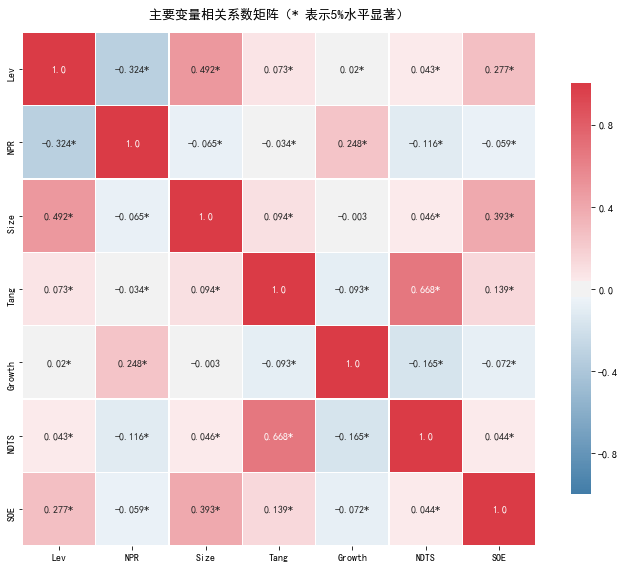

热力图已保存至 ./output/figures/fig3_correlation_heatmap.png


In [11]:
# （标注5%显著性）
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

# 选择变量（含 SOE）
corr_vars = ['Lev_w', 'NPR_w', 'Size', 'Tang_w', 'Growth_w', 'NDTS_w', 'SOE']
corr_labels = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE']

corr_df = df[corr_vars].dropna()
corr_mat = corr_df.corr()

# 显著性检验（5%）
n = corr_df.shape[0]
p_mat = corr_mat.copy()
for i in range(p_mat.shape[0]):
    for j in range(p_mat.shape[1]):
        r = corr_mat.iloc[i, j]
        if i == j:
            p_mat.iloc[i, j] = 0
        else:
            t_stat = r * np.sqrt((n-2)/(1-r**2))
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
            p_mat.iloc[i, j] = p_val

# 生成带星号标注的矩阵
annot_mat = corr_mat.round(3).astype(str).copy()
for i in range(annot_mat.shape[0]):
    for j in range(annot_mat.shape[1]):
        if i != j and p_mat.iloc[i, j] < 0.05:
            annot_mat.iloc[i, j] += '*'

# ------------ 调整颜色映射 ------------
# 使用 'coolwarm' 配色，比 'RdBu_r' 更柔和，学术论文常用
cmap = sns.diverging_palette(240, 10, as_cmap=True)
# 你也可以尝试下面这几款，选你喜欢的替换上一行即可：
# cmap = 'coolwarm'
# cmap = 'vlag'
# cmap = 'RdBu_r'   # 之前那个

# 画热力图
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_mat, annot=annot_mat.values, fmt='', 
                 cmap=cmap,                    # 新配色
                 vmin=-1, vmax=1, center=0,
                 xticklabels=corr_labels, yticklabels=corr_labels,
                 square=True,
                 linewidths=0.5,              # 加网格线，更清晰
                 cbar_kws={'shrink': 0.8})
ax.set_title('主要变量相关系数矩阵（* 表示5%水平显著）', fontsize=13, pad=15)

# 保存
os.makedirs('./output/figures/', exist_ok=True)
plt.tight_layout()
plt.savefig('./output/figures/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("热力图已保存至 ./output/figures/fig3_correlation_heatmap.png")

#### 相关系数矩阵分析

**（1）NPR 与 Lev 的相关系数方向**
- NPR 与 Lev 的相关系数为 **-0.324\***，在5%水平下显著为负。盈利能力越强，企业杠杆率越低，这一结果为**优序融资理论**提供了初步证据——盈利企业优先使用内源资金偿还债务或避免新增负债。

**（2）Size 与 NPR 的相关系数**
- Size 与 NPR 的相关系数为 **-0.065\***，虽绝对值较小但在统计上显著。这表明企业规模越大，资产收益率反而略低，可能反映规模报酬递减或大企业更注重稳健经营。这一关系为后续函数系数模型（M5）中“信息不对称程度随规模变化”的假设提供了初步依据——小企业信息不对称更高，其 NPR-Lev 关系可能更不线性。

**（3）多重共线性诊断**
- 所有变量对间的相关系数绝对值均小于 0.7，不存在严重的多重共线性。
- 相对较高的相关对为：**Tang 与 NDTS（0.668\*）**、**Lev 与 Size（0.492\*）**、**Size 与 SOE（0.393\*）**。Tang 与 NDTS 的正相关在预期之中——固定资产比例高的企业折旧摊销自然也高。Size 与 Lev 的正相关符合权衡理论。Size 与 SOE 的正相关反映国有企业规模普遍较大。
- 这些共线性程度不影响回归估计的可靠性。

### 2.3 时序趋势图

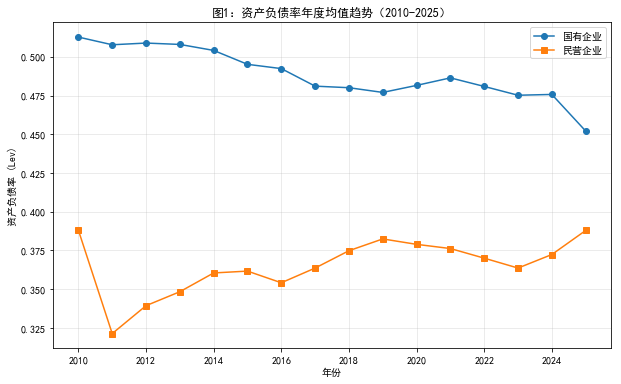

In [12]:
# ============================================================
# 图1：Lev 年度均值时序（分 SOE/非SOE）
# ============================================================
import matplotlib.pyplot as plt

lev_soe = df[df['SOE']==1].groupby('year')['Lev_w'].mean()
lev_private = df[df['SOE']==0].groupby('year')['Lev_w'].mean()

plt.figure(figsize=(10,6))
plt.plot(lev_soe.index, lev_soe.values, 'o-', label='国有企业')
plt.plot(lev_private.index, lev_private.values, 's-', label='民营企业')
plt.xlabel('年份')
plt.ylabel('资产负债率 (Lev)')
plt.title('图1：资产负债率年度均值趋势（2010-2025）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./output/figures/fig1_lev_trend.png', dpi=150)
plt.show()

#### 2.3.1. 资产负债率时序趋势分析（按产权分组）

图 1 展示了 2010 年至 2025 年国有企业与民营企业资产负债率均值的演变路径。从图中可以观察到以下显著特征：

-**产权差异显著且持续**：国有企业的资产负债率在整段样本期内均明显高于民营企业，差距约10-15个百分点。这反映了国有企业在信贷可得性、融资成本和政府隐性担保方面的系统性优势。
- **国有企业经历明显去杠杆历程**：国企杠杆率从2010年约0.51的高位持续下行，至2016-2020年间趋于平稳（约0.46-0.48），2020年后再度小幅走低。这与国家持续推进的国有企业去杠杆、供给侧结构性改革等政策方向高度吻合。
- **民营企业杠杆率相对平稳**：民企杠杆率在2010-2025年间波动较小，整体在0.32-0.40区间，没有出现类似国企的大幅趋势性变化，说明民企面临的融资约束使其杠杆调整空间有限。
- **差距收敛迹象**：2020年后国企与民企的杠杆率差距有所缩小，国企降幅更明显，可能与国企债务约束硬化、民企融资环境边际改善有关。


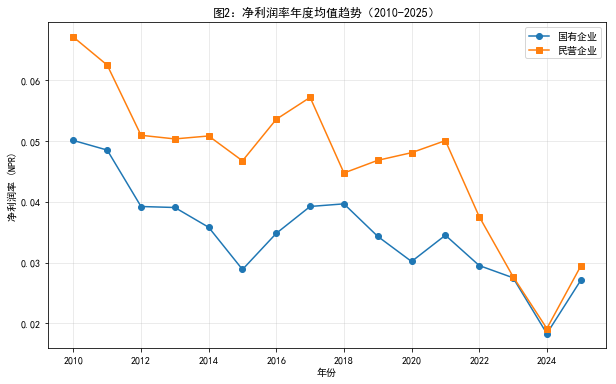

In [13]:
# ============================================================
# 图2：NPR 年度均值时序（分 SOE/非SOE）
# ============================================================
npr_soe = df[df['SOE']==1].groupby('year')['NPR_w'].mean()
npr_private = df[df['SOE']==0].groupby('year')['NPR_w'].mean()

plt.figure(figsize=(10,6))
plt.plot(npr_soe.index, npr_soe.values, 'o-', label='国有企业')
plt.plot(npr_private.index, npr_private.values, 's-', label='民营企业')
plt.xlabel('年份')
plt.ylabel('净利润率 (NPR)')
plt.title('图2：净利润率年度均值趋势（2010-2025）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./output/figures/fig2_npr_trend.png', dpi=150)
plt.show()

#### 2.3.2. 净利润率时序趋势分析（按产权分组）

图 2 描绘了样本期间企业盈利能力（净利润/总资产）的动态变化：

- **整体下降趋势明显**：两类企业的净利润率在样本期内均呈现波动下降态势，尤其2021年后加速下行，反映宏观经济增长放缓、成本上升和竞争加剧对企业盈利的持续挤压。
- **前期国企利润波动更大**：2010-2015年间国企NPR从高位回落幅度较大，可能与“四万亿”后期产能过剩、利润收窄有关。
- **波动特征**：相比资产负债率，净利润率的年度波动更为剧烈，且国企与民企的相对优势发生了多次变化。
- **民营企业（橙线）**：在2010-2011年处于高位（0.06以上），显著高于国企。随后大幅回落，在2012-2021年的大部分时间里，维持在0.045-0.055的区间震荡。
- **国有企业（蓝线）**：呈现长期缓慢下降趋势。从2010年的0.05一路震荡下行，在2015年和2022年出现两个明显的低谷。
- **关键交汇点**：
  - **2022年**：两条线发生交叉。在此之前，民企利润率总体高于国企；在此之后，两者差距迅速缩小。
  - **2024年（全样本低谷）**：这是图中最显著的视觉特征。无论国企还是民企，净利润率均在2024年出现了断崖式下跌，双双跌至全样本最低点（约0.018-0.020）。
  - **2025年（反弹）**：在2024年的低谷后，两条线在2025年均出现了同步的显著反弹，回升至0.03左右。

<Figure size 1008x432 with 0 Axes>

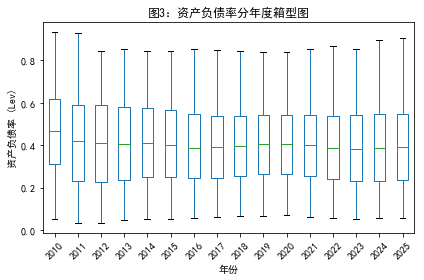

In [14]:
# ============================================================
# 图3：Lev 分年度箱型图
# ============================================================
plt.figure(figsize=(14,6))
df.boxplot(column='Lev_w', by='year', grid=False, showfliers=False)
plt.title('图3：资产负债率分年度箱型图')
plt.suptitle('')
plt.xlabel('年份')
plt.ylabel('资产负债率 (Lev)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./output/figures/fig3_lev_boxplot_by_year.png', dpi=150)
plt.show()

#### 2.3.3. 资产负债率分布的分年度箱型图分析

图 3 展示了 2010 年至 2025 年全样本资产负债率的分布形态及其时序变化：

- **集中趋势**：箱体内的中位数（绿色横线）在2010-2025年间保持了极高稳定性，始终维持在0.40-0.45之间，说明大部分企业的负债水平并未随时间发生剧烈改变。
- **离散程度**：箱体的高度（四分位差）和须的长度（最大/最小值范围）在各年份间变化不大，表明样本企业间的杠杆率差异结构相对稳定。
- **离群值持续存在**：每年箱体上缘以上均有大量离群点，说明始终有企业维持极高杠杆
- **波动幅度稳定**：箱体高度（IQR）在期间内无明显趋势变化，企业间杠杆率的离散程度保持恒定。